# Step 4: Compute a layered layout

-	consider you have a directed graph
-	constract a DAG (directed acyclic graph) by reversing edges - use either the trivial heuristic or the one with guarantees (Eades at al. 93)
-	perform layer assignment (using height minimization)
-	perform iterative crossing minimization using both median and barycenter heuristics
-	assign coordinates to the vertices in any way you like and draw the edges
-	reverse back the edges that have been changed in the first step
-	use Small Directed Network, Pro League Network at this step to experiment with your algorithm.
-	discuss your results and explain your choices of the heuristics carefully. Feel free to use other heuristics for each step but do not forget to explain your choices.


Libraries:

In [16]:
import pandas as pd
import numpy as np
import pydot
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, ConnectionPatch
import graphviz
import networkx as nx
from networkx.drawing.nx_pydot import from_pydot
from collections import deque
import os
import math
import random
import re
from pathlib import Path

Graph Datasets

In [19]:
#names of the dot files that contain the data:
data_name_1 = "../Dataset/JazzNetwork.dot"
data_name_2 = "../Dataset/LesMiserables.dot"
data_name_3 = "../Dataset/devonshiredebate_withclusters.dot"
data_name_4 = "../Dataset/g.20.27.dot"
data_name_5 = "../Dataset/g.42.88.dot"
data_name_6 = "../Dataset/GD97.dot"
data_name_7 = "../Dataset/LeagueNetwork.dot" #
data_name_8 = "../Dataset/mesh graph.dot"
data_name_9 = "../Dataset/noname.dot" #
data_name_10 = "../Dataset/polblogs.dot"
data_name_11 = "../Dataset/robot graph.dot"
data_name_12 = "../Dataset/rome.dot"
data_name_13 = "../Dataset/snail graph.dot"

Main Functions:

# Circular layout

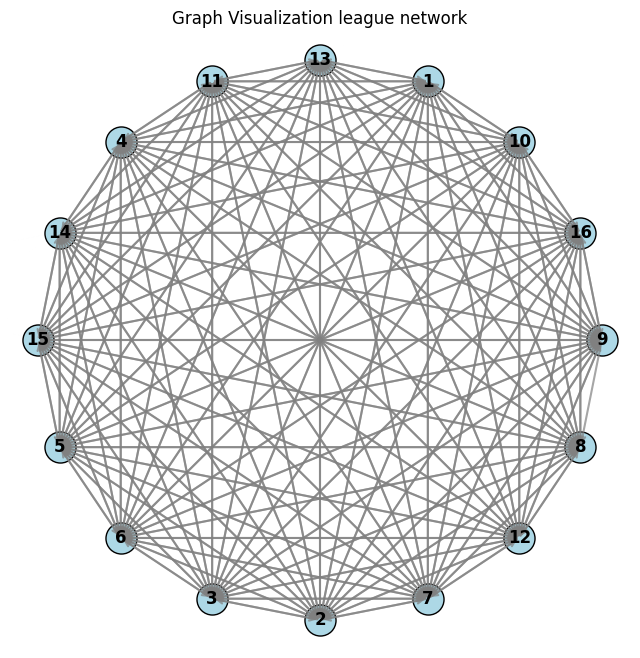

In [20]:
import matplotlib.pyplot as plt
import pydot
import numpy as np

def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0]  
    nodes = set()
    edges = []

    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def circular_visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib."""
    V = len(nodes)
    
    # Assign positions to nodes (circular layout)
    theta = np.linspace(0, 2 * np.pi, V, endpoint=False)
    node_positions = {node: (np.cos(theta[i]), np.sin(theta[i])) for i, node in enumerate(nodes)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("Graph Visualization league network")
    plt.show()

#use a file
dot_file = data_name_7 
nodes, edges = parse_dot_file(dot_file)
circular_visualize_graph(nodes, edges)


# Random Position

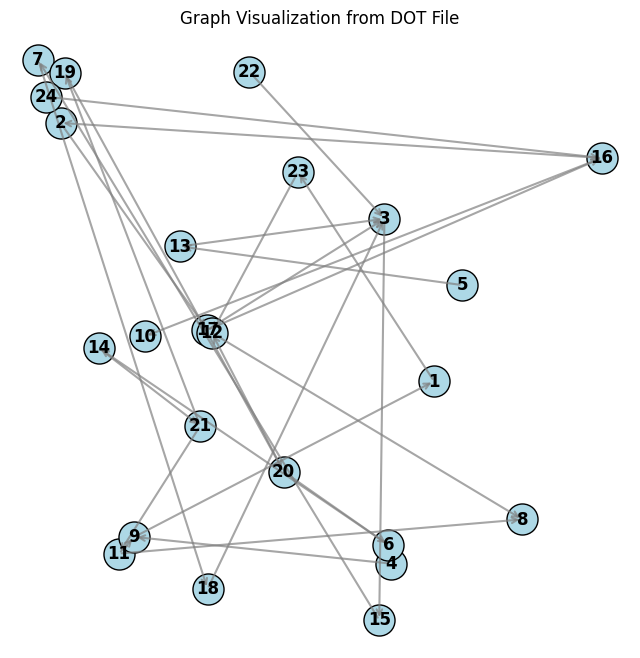

In [21]:
import matplotlib.pyplot as plt
import pydot
import numpy as np

def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0] 
    nodes = set()
    edges = []

    # Extract edges and nodes
    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def random_visualize_graph(nodes, edges):
    """Plot the directed graph using Matplotlib in a more traditional layout."""
    V = len(nodes)
    
    # Assign random positions to nodes for a more spread-out layout
    np.random.seed(42)  # Set seed for reproducibility
    node_positions = {node: (np.random.uniform(-1, 1), np.random.uniform(-1, 1)) for node in nodes}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    # Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')

    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("Graph Visualization from DOT File")
    plt.show()


dot_file = data_name_9  
nodes, edges = parse_dot_file(dot_file)
random_visualize_graph(nodes, edges)


# Using DFS

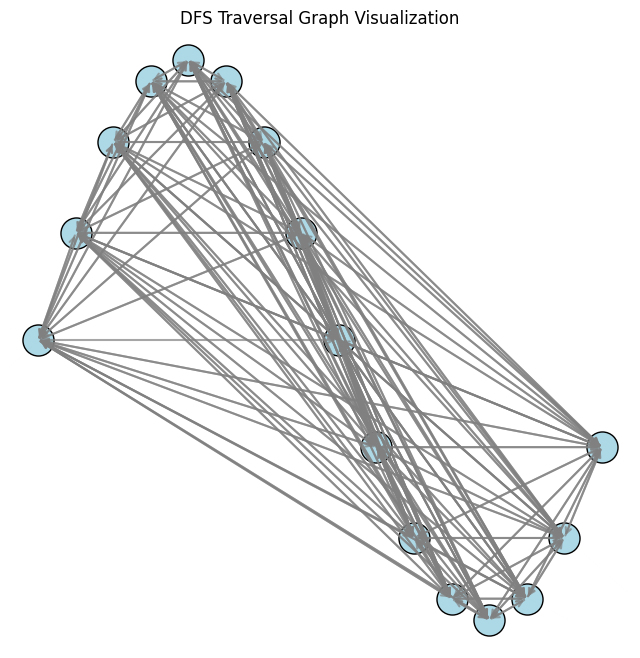

In [22]:
import matplotlib.pyplot as plt
import pydot
import numpy as np

def parse_dot_file(file_path):
    """Parse DOT file and extract nodes and edges."""
    graph = pydot.graph_from_dot_file(file_path)[0] 
    nodes = set()
    edges = []

    # Extract edges and nodes
    for edge in graph.get_edges():
        src, dst = edge.get_source(), edge.get_destination()
        nodes.add(src)
        nodes.add(dst)
        edges.append((src, dst))

    return list(nodes), edges

def dfs(graph, start, visited, result):
    """DFS traversal of the graph."""
    visited.add(start)
    result.append(start)
    
    # Visit all neighbors
    for neighbor in graph[start]:
        if neighbor not in visited:
            dfs(graph, neighbor, visited, result)

def sin_visualize_graph(nodes, edges):
    """Plot the directed graph using DFS order."""
    # Create an adjacency list for DFS traversal
    adj_list = {node: [] for node in nodes}
    for src, dst in edges:
        adj_list[src].append(dst)

    # Perform DFS starting from an arbitrary node (first node in the list)
    visited = set()
    dfs_result = []
    dfs(adj_list, nodes[0], visited, dfs_result)

    # Assign positions based on DFS result (sequential order)
    V = len(nodes)
    node_positions = {node: (i / V * 2 - 1, np.sin(i / V * 2 * np.pi)) for i, node in enumerate(dfs_result)}

    # Plot nodes
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.scatter(*zip(*node_positions.values()), s=500, c="lightblue", edgecolors="black", zorder=2)

    # Plot directed edges
    for src, dst in edges:
        x1, y1 = node_positions[src]
        x2, y2 = node_positions[dst]
        ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle="->", color="gray", lw=1.5, alpha=0.7))

    """# Label nodes
    for node, (x, y) in node_positions.items():
        ax.text(x, y, node, fontsize=12, ha='center', va='center', fontweight='bold')
    """
    # Hide axes
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_frame_on(False)

    plt.title("DFS Traversal Graph Visualization")
    plt.show()


dot_file = data_name_7  
nodes, edges = parse_dot_file(dot_file)
sin_visualize_graph(nodes, edges)


# Resolve cycles

In [83]:
def eades_lin_smith_fas(nodes, edges):
    """
    Implements the Eades, Lin & Smith algorithm for the Minimum Feedback Arc Set.
    
    Input:
        nodes: list of nodes
        edges: list of tuples (source_node, target_node)
    
    Output:
        A: list of edges to keep as they are
        A_reverse: list of edges to be reversed
    """
    # Create the graph as a dictionary {node: [adjacent_nodes]}
    graph = {node: [] for node in nodes}
    for source, target in edges:
        if source in graph:
            graph[source].append(target)
    
    # Create lists to store the edges
    A = []          # edges to keep
    A_reverse = []  # edges to reverse
    
    # Calculate indegree for each node
    in_degree = {node: 0 for node in graph}
    for node in graph:
        for neighbor in graph[node]:
            if neighbor in in_degree:  # Ensure the node exists in the dictionary
                in_degree[neighbor] = in_degree.get(neighbor, 0) + 1
    
    # Continue until there are no nodes left in the graph
    while graph:
        # Step 1.1: Find sink and source nodes
        sinks = [node for node in graph if not graph[node]]
        sources = [node for node in graph if in_degree[node] == 0]
        
        # Step 1.2: Remove sink nodes
        while sinks:
            sink = sinks.pop()
            # Add the incoming edges of the sink to A
            for node in list(graph.keys()):
                if sink in graph[node]:
                    A.append((node, sink))
                    graph[node].remove(sink)
                    in_degree[sink] -= 1
            # Remove the sink node from the graph
            del graph[sink]
        
        # Step 1.3: Remove isolated nodes
        isolated = [node for node in graph if not graph[node] and in_degree[node] == 0]
        for node in isolated:
            del graph[node]
        
        # Step 1.4: Remove source nodes
        while sources:
            source = sources.pop()
            # Add the outgoing edges of the source to A
            for neighbor in list(graph[source]):
                A.append((source, neighbor))
                graph[source].remove(neighbor)
                in_degree[neighbor] -= 1
                # Check if the neighbor has become a source
                if in_degree[neighbor] == 0 and neighbor in graph and neighbor not in sources:
                    sources.append(neighbor)
            # Remove the source node from the graph
            del graph[source]
        
        # Step 1.5: If there are still nodes, select the one with max(outdegree - indegree)
        if graph:
            # Calculate outdegree - indegree for each node
            diff_degree = {node: len(graph[node]) - in_degree[node] for node in graph}
            
            # Find the node with the maximum difference
            max_diff_node = max(diff_degree, key=diff_degree.get)
            
            # Add the node's edges to A_reverse
            for neighbor in list(graph[max_diff_node]):
                A_reverse.append((max_diff_node, neighbor))
                graph[max_diff_node].remove(neighbor)
                in_degree[neighbor] -= 1
            
            # Remove the node from the graph
            del graph[max_diff_node]
    
    return A, A_reverse

def reversed_edges(A, A_reverse):
    """Return the reversed edges."""
    A_reversed = [(dst, src) for src, dst in A_reverse]
    final_reversed = A_reversed + A
    
    return final_reversed

In [84]:
# example graph.
test_nodes = ['A', 'B', 'C', 'D', 'E', 'F']
test_edges = [
    ('A', 'B'),  # A → B
    ('B', 'C'),  # B → C
    ('C', 'D'),  # C → D
    ('D', 'B'),  # D → B (this creates a loop: B → C → D → B)
    ('E', 'A'),  # E → A
    ('C', 'F')   # C → F
]

# algorithm test
A, A_reverse = eades_lin_smith_fas(test_nodes, test_edges)
final_edges = reversed_edges(A, A_reverse)

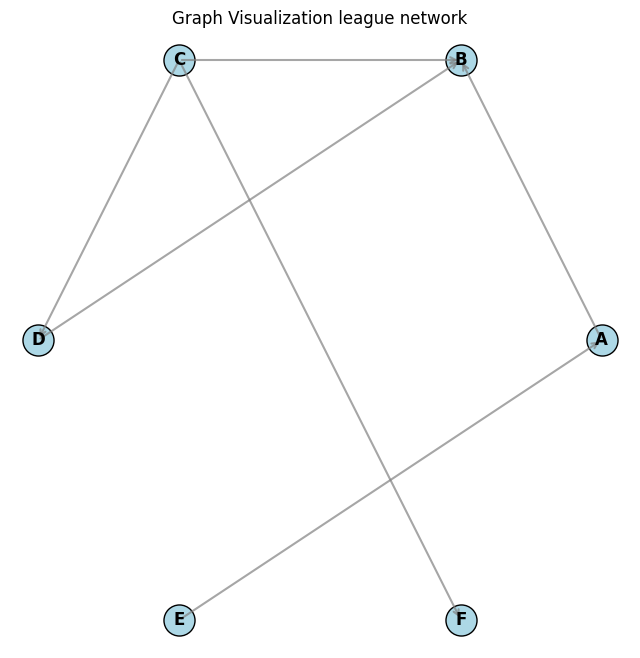

In [92]:
circular_visualize_graph(test_nodes, final_edges)

## League Network

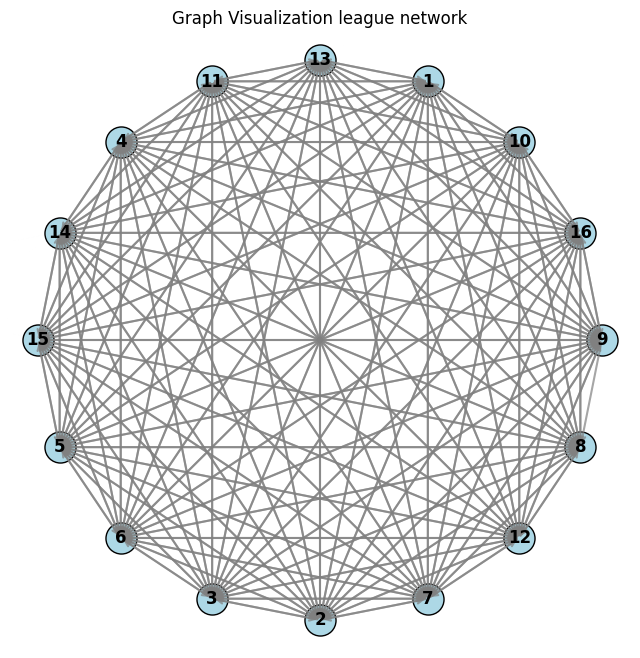

In [89]:
dot_file = data_name_7 # league network 
nodes, edges = parse_dot_file(dot_file)
circular_visualize_graph(nodes, edges)

KeyError: 'C'

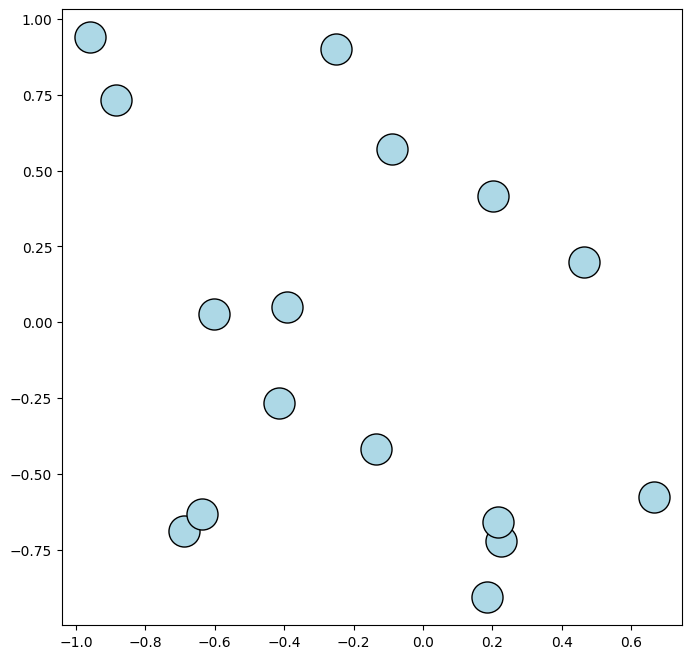

In [91]:
# algorithm test
A, A_reverse = eades_lin_smith_fas(test_nodes, test_edges)
final_edges = reversed_edges(A, A_reverse)
random_visualize_graph(nodes, final_edges)

## No name

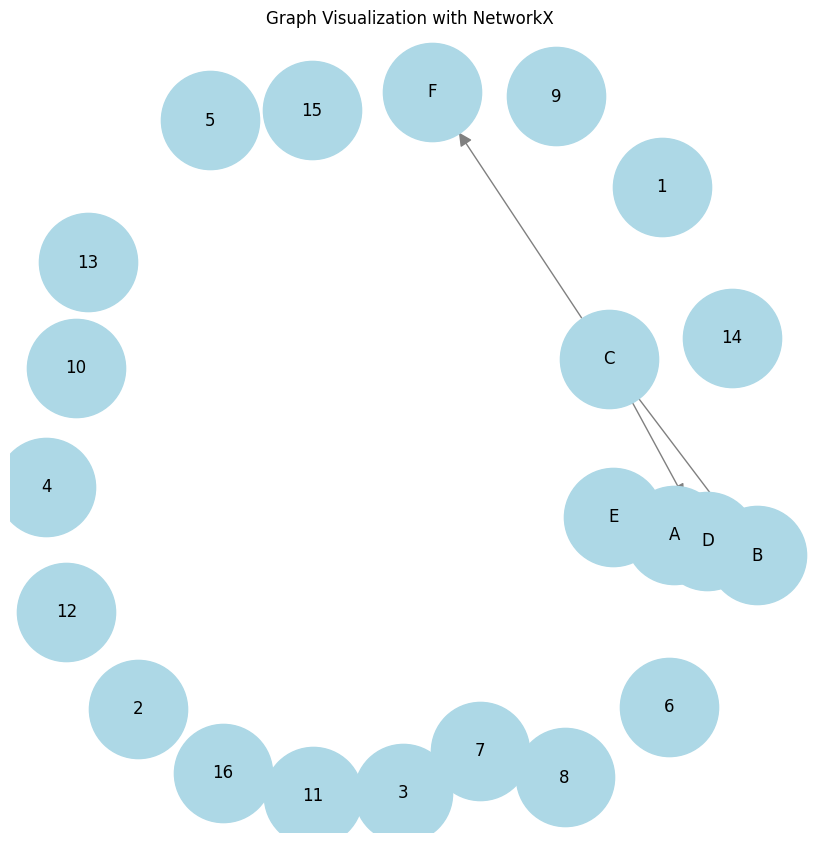

In [97]:
dot_file = data_name_7 # league network 
nodes, edges = parse_dot_file(dot_file)
# algorithm test
A, A_reverse = eades_lin_smith_fas(test_nodes, test_edges)
final_edges = reversed_edges(A, A_reverse)
visualize_graph_with_networkx(nodes, final_edges)

# Layer assignment

# Crossing minimization

# Node positioning

# Edge drawing

# Edge reversing